In [12]:
import os
import gc
import json
import torch
import pandas as pd
import numpy as np
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score
from transformers import AutoTokenizer, get_linear_schedule_with_warmup

# Import modularized architectures and datasets
import sys
sys.path.append('..')
from models.transformers import UniversalTransformerClassifier
from src.data_utils import BertDataset

# Configuration
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROCESSED_DIR = './Touche_Data/processed'
MODELS_DIR = './models/saved_weights'
os.makedirs(MODELS_DIR, exist_ok=True)

torch.manual_seed(SEED)
print(f"✅ Training on device: {DEVICE}")

# Load splits
train_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'train.csv'))
val_df = pd.read_csv(os.path.join(PROCESSED_DIR, 'val.csv'))

LABEL_COLS = [c for c in train_df.columns if c not in ['Argument ID', 'text_raw', 'text_clean']]
y_train = train_df[LABEL_COLS].values
y_val = val_df[LABEL_COLS].values

# Initialize Tokenizer
MODEL_NAME = 'roberta-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_loader = DataLoader(BertDataset(train_df['text_raw'].values, y_train, tokenizer), batch_size=16, shuffle=True)
val_loader = DataLoader(BertDataset(val_df['text_raw'].values, y_val, tokenizer), batch_size=16)

✅ Training on device: cuda


In [ ]:
def calculate_pos_weights(y):
    """function to penalize imbalanced predictions and promote generalization"""
    pos_counts = np.maximum(y.sum(axis=0), 1)
    total_counts = y.shape[0]
    weights = np.sqrt((total_counts - pos_counts) / pos_counts)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)

def train_model(model, train_loader, val_loader, pos_weights, epochs=10, lr=2e-5):
    model = model.to(DEVICE)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * total_steps), total_steps)

    best_f1, best_state = 0, None
    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            input_ids, mask, labels = batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE), batch['labels'].to(DEVICE)
            outputs = model(input_ids, mask)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
                
        # Validation (using 0.5 threshold for tracking)
        model.eval()
        all_probs = []
        with torch.no_grad():
            for batch in val_loader:
                outputs = model(batch['input_ids'].to(DEVICE), batch['attention_mask'].to(DEVICE))
                all_probs.extend(torch.sigmoid(outputs).cpu().numpy())
        
        val_f1 = f1_score(y_val, (np.array(all_probs) > 0.5).astype(int), average='macro', zero_division=0)
        print(f"Epoch {epoch+1}/{epochs} | Val F1: {val_f1:.4f}")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
    model.load_state_dict(best_state)
    return model

# Execute Training
pos_weights = calculate_pos_weights(y_train)
roberta_model = UniversalTransformerClassifier(model_name=MODEL_NAME).to(DEVICE)
trained_roberta = train_model(roberta_model, train_loader, val_loader, pos_weights)
torch.save(trained_roberta.state_dict(), os.path.join(MODELS_DIR, 'roberta_best.pt'))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/10 | Val F1: 0.4328
Epoch 2/10 | Val F1: 0.5182
Epoch 3/10 | Val F1: 0.5381
Epoch 4/10 | Val F1: 0.5423
Epoch 5/10 | Val F1: 0.5529
Epoch 6/10 | Val F1: 0.5490
Epoch 7/10 | Val F1: 0.5481
Epoch 8/10 | Val F1: 0.5396
Epoch 9/10 | Val F1: 0.5422
Epoch 10/10 | Val F1: 0.5394


Now we test inference on this toy dataset

In [ ]:
# 4. TOY INFERENCE
print("Running Toy Inference...")
toy_data = []
with open('parlamint_arguments_dataset_TOY.jsonl', 'r') as f:
    for line in f: toy_data.append(json.loads(line))
toy_df = pd.DataFrame(toy_data)
toy_df['text_raw'] = toy_df['Conclusion'] + " " + toy_df['Stance'] + " " + toy_df['Premise']

trained_roberta.eval()
results = []
with torch.no_grad():
    for _, row in toy_df.iterrows():
        inputs = tokenizer(row['text_raw'], truncation=True, padding='max_length', max_length=128, return_tensors='pt').to(DEVICE)
        probs = torch.sigmoid(trained_roberta(inputs['input_ids'], inputs['attention_mask'])).cpu().numpy()[0]
        # Using the Mean Optimal Threshold of 0.49 found in assessment 2
        active_labels = [LABEL_COLS[i] for i, p in enumerate(probs) if p > 0.49]
        results.append({"Speaker": row['Speaker'], "Values": active_labels})

results_df = pd.DataFrame(results)
display(results_df)

🎯 Running Toy Inference...


,Speaker,Values
0,"Sánchez Pérez-Castejón, Pedro","[Achievement, Power: dominance, Power: resourc..."
1,"Sánchez Pérez-Castejón, Pedro","[Achievement, Power: resources, Universalism: ..."
2,"Sánchez Pérez-Castejón, Pedro","[Achievement, Power: resources, Universalism: ..."
3,"Sánchez Pérez-Castejón, Pedro","[Conformity: rules, Benevolence: caring, Unive..."
4,"Sánchez Pérez-Castejón, Pedro","[Self-direction: action, Power: dominance, Uni..."
5,"Sánchez Pérez-Castejón, Pedro","[Achievement, Power: dominance, Security: soci..."
6,"Sánchez Pérez-Castejón, Pedro","[Achievement, Power: dominance, Security: soci..."
7,"Sánchez Pérez-Castejón, Pedro","[Power: resources, Security: personal, Univers..."
8,"Sánchez Pérez-Castejón, Pedro","[Power: resources, Security: personal, Univers..."
9,"Sánchez Pérez-Castejón, Pedro","[Universalism: concern, Universalism: toleranc..."


Now we visualize the radars at different levels of specifity: 
- Level 1 (Specific): The 20 raw categories your model predicts (e.g., Power: dominance, Universalism: objectivity).

- Level 2 (Basic): 10-12 aggregated values (e.g., Power, Universalism, Conformity).

- Level 3 (Higher-Order): 4 broad motivational pillars (Openness to Change, Conservation, Self-Enhancement, Self-Transcendence).

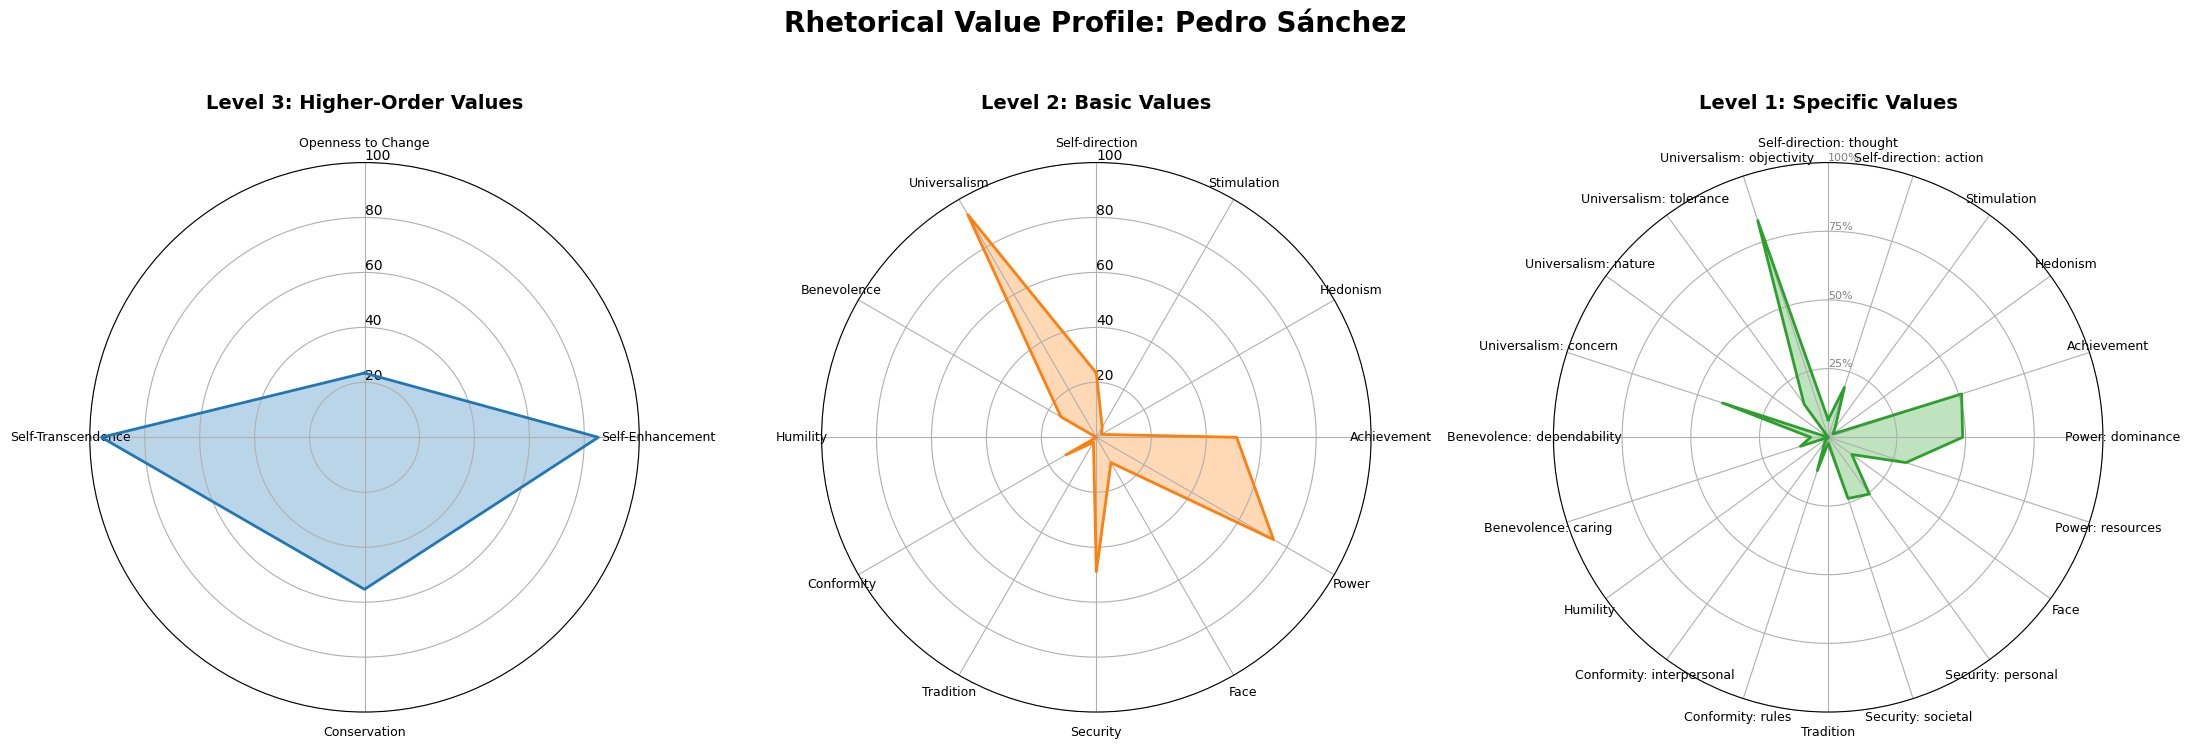

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# 1. Filter for Pedro Sánchez
sanchez_df = results_df[results_df['Speaker'] == 'Sánchez Pérez-Castejón, Pedro']
total_speeches = len(sanchez_df)

# 2. Define the Schwartz Value Hierarchies
higher_order_map = {
    'Openness to Change': ['Self-direction: thought', 'Self-direction: action', 'Stimulation'],
    'Self-Enhancement': ['Hedonism', 'Achievement', 'Power: dominance', 'Power: resources', 'Face'],
    'Conservation': ['Security: personal', 'Security: societal', 'Tradition', 'Conformity: rules', 'Conformity: interpersonal', 'Humility'],
    'Self-Transcendence': ['Benevolence: caring', 'Benevolence: dependability', 'Universalism: concern', 'Universalism: nature', 'Universalism: tolerance', 'Universalism: objectivity']
}

basic_map = {
    'Self-direction': ['Self-direction: thought', 'Self-direction: action'],
    'Stimulation': ['Stimulation'],
    'Hedonism': ['Hedonism'],
    'Achievement': ['Achievement'],
    'Power': ['Power: dominance', 'Power: resources'],
    'Face': ['Face'],
    'Security': ['Security: personal', 'Security: societal'],
    'Tradition': ['Tradition'],
    'Conformity': ['Conformity: rules', 'Conformity: interpersonal'],
    'Humility': ['Humility'],
    'Benevolence': ['Benevolence: caring', 'Benevolence: dependability'],
    'Universalism': ['Universalism: concern', 'Universalism: nature', 'Universalism: tolerance', 'Universalism: objectivity']
}

# The 20 specific values
specific_values = [
    'Self-direction: thought', 'Self-direction: action', 'Stimulation', 'Hedonism', 
    'Achievement', 'Power: dominance', 'Power: resources', 'Face', 
    'Security: personal', 'Security: societal', 'Tradition', 'Conformity: rules', 
    'Conformity: interpersonal', 'Humility', 'Benevolence: caring', 
    'Benevolence: dependability', 'Universalism: concern', 'Universalism: nature', 
    'Universalism: tolerance', 'Universalism: objectivity'
]

# 3. Helper function to calculate frequency percentage
def get_frequencies(df, mapping=None, specific_list=None):
    freqs = {}
    if mapping:
        for category, sub_values in mapping.items():
            # Count speeches that contain AT LEAST ONE value from this category
            count = sum(1 for vals in df['Values'] if any(v in vals for v in sub_values))
            freqs[category] = (count / total_speeches) * 100
    else:
        for val in specific_list:
            count = sum(1 for vals in df['Values'] if val in vals)
            freqs[val] = (count / total_speeches) * 100
    return freqs

# Get frequencies for all 3 levels
freq_higher = get_frequencies(sanchez_df, mapping=higher_order_map)
freq_basic = get_frequencies(sanchez_df, mapping=basic_map)
freq_specific = get_frequencies(sanchez_df, specific_list=specific_values)

# 5. Radar Chart Plotting Function
def plot_radar(ax, data_dict, title, color):
    categories = list(data_dict.keys())
    values = list(data_dict.values())
    
    # Number of variables
    N = len(categories)
    
    # Calculate angles for each category
    angles = [n / float(N) * 2 * pi for n in range(N)]
    values += values[:1] # Close the circle
    angles += angles[:1] # Close the circle
    
    # Plotting
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw axis lines and labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9, wrap=True)
    
    # Draw y-tick labels (percentages)
    ax.set_rlabel_position(0)
    plt.yticks([25, 50, 75, 100], ["25%", "50%", "75%", "100%"], color="grey", size=8)
    ax.set_ylim(0, 100)
    
    # Fill area
    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.3)
    ax.set_title(title, size=14, weight='bold', pad=20)

# 6. Render the 3 Subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 7), subplot_kw=dict(polar=True))
fig.suptitle("Rhetorical Value Profile: Pedro Sánchez", fontsize=20, weight='bold', y=1.05)

plot_radar(axes[0], freq_higher, "Level 3: Higher-Order Values", "#1f77b4")
plot_radar(axes[1], freq_basic, "Level 2: Basic Values", "#ff7f0e")
plot_radar(axes[2], freq_specific, "Level 1: Specific Values", "#2ca02c")

plt.tight_layout()
plt.savefig("sanchez_radar.png", dpi=400)
plt.show()